# Machine Learning 

## Section 2, Part c: Cross Validation 


Objetivos de aprendizaje
Al final de esta lección, serás:

* Encadenar múltiples pasos de procesamiento de datos usando `Pipeline`
* Usa el objeto `KFolds`  para dividir los datos en múltiples pliegues.
* Realizar validación cruzada usando SciKit -Learn con `cross_val_predict` y `GridSearchCV`

In [1]:
# Surpress warnings:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn
#!pip install numpy
#!pip install pandas
#!pip install matplotlib
#!pip install scikit-learn
import numpy as np
import pickle
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline

In [2]:
# Note we are loading a slightly different ("cleaned") pickle file
#!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML240EN-SkillsNetwork/labs/data/boston_housing_clean.pickle
# boston = pickle.load(open('data/boston_housing_clean.pickle', "rb" ))
boston = pickle.load(open('boston_housing_clean.pickle', "rb" ))

In [3]:
boston.keys()

dict_keys(['dataframe', 'description'])

In [4]:
!python --version

Python 3.12.7


In [9]:
boston_data = boston['dataframe']
boston_description = boston['description']

In [11]:
boston_data.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


###  Discusión:
Supongamos que queremos hacer regresión lineal en nuestro conjunto de datos para obtener una estimación, basada en el error cuadrático medio, de cómo funcionará nuestro modelo con datos fuera de nuestro conjunto.

Supongamos también que nuestros datos se dividen en tres partes: Fold 1, Fold 2 y Fold 3.


#### Codificando esto
El objeto [`KFold`](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html) en SciKit Learn indica al objeto de validación cruzada (ver más abajo) cómo dividir los datos:

In [13]:
X = boston_data.drop('MEDV', axis=1)
y = boston_data.MEDV

In [15]:
kf = KFold(shuffle=True, random_state=72018, n_splits=3)

El código <code> kf = KFold(shuffle=True, random_state=72018, n_splits=3) </code>  crea una instancia de la clase `KFold` del módulo `sklearn.model_selection`. 

Esta clase se utiliza para dividir los datos en "folds" o subconjuntos para realizar validación cruzada (cross-validation). A continuación se explica qué hace cada parámetro:

1. <code> shuffle=True: </code> 
   - Indica que los datos serán barajados aleatoriamente antes de dividirse en los diferentes "folds". 
   - Sin esta opción, los datos se dividirían en el mismo orden en que están, lo cual podría sesgar el proceso si los datos tienen un orden específico (por ejemplo, si están ordenados cronológicamente).

2. <code>random_state=72018: </code> 
   - Este es un valor utilizado para inicializar el generador de números aleatorios. 
   - El valor específico (en este caso, 72018) asegura que el proceso de aleatorización sea reproducible. Es decir, cada vez que ejecutes este código, la división de los datos será la misma, lo que es útil para asegurar la consistencia en los experimentos.

3. <code> n_splits=3 </code> 
   - Define en cuántos subconjuntos o "folds" se dividirán los datos.
   - En este caso, los datos serán divididos en 3 partes. Esto significa que se entrenará el modelo 3 veces, cada vez con 2 de los 3 subconjuntos para entrenamiento y el tercero para validación.

### Resumen
Este código configura una validación cruzada con 3 "folds", baraja los datos antes de hacer la división, y garantiza que la división sea la misma en cada ejecución gracias al parámetro <code> random_state </code> . 


Esto ayuda a obtener una evaluación más robusta del modelo, ya que utiliza diferentes subconjuntos de datos para entrenar y validar.


Este fragmento de código imprime los índices de los datos que se usan para entrenamiento y prueba en cada iteración de la validación cruzada. Utiliza <code> KFold </code> para dividir el conjunto de datos X en "folds", y en cada ciclo muestra:

* Los primeros 10 índices del conjunto de entrenamiento.

* Los primeros 10 índices del conjunto de prueba.

* El número total de índices en cada conjunto.

In [17]:
for train_index, test_index in kf.split(X): #Solo obtiene índices (independiente si pones X o Y)
    print("Train index:", train_index[:10], len(train_index)) #Imprime los primeros 10 valores y pone el no. de valores 
    print("Test index:",test_index[:10], len(test_index))  #Imprime los primeros 10 valores y pone el no. de valores 
    print('')

Train index: [ 1  3  4  5  7  8 10 11 12 13] 337
Test index: [ 0  2  6  9 15 17 19 23 25 26] 169

Train index: [ 0  2  6  9 10 11 12 13 15 17] 337
Test index: [ 1  3  4  5  7  8 14 16 22 27] 169

Train index: [0 1 2 3 4 5 6 7 8 9] 338
Test index: [10 11 12 13 18 20 21 24 28 31] 168



In [19]:
scores = []  # Lista vacía donde se guardarán los puntajes (R²) de cada fold.
lr = LinearRegression()  # Se crea una instancia del modelo de regresión lineal.
lr

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


$$
R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}
{\sum_{i=1}^{n} (y_i - \bar{y})^2} = 1 - \frac{SSE}{SST}
$$


**Suma de Cuadrados del Error (SSE o RSS)** 
La **Suma de Cuadrados del Error** (también conocida como **Error cuadrático residual** o **RSS**, por sus siglas en inglés) mide la **diferencia entre los valores reales** ($y_i$) y los **valores predichos** ($\hat{y}_i$) por el modelo.

La fórmula es:

$$
\sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

- $y_i$ = valor real (observado)
- $\hat{y}_i$ = valor predicho (estimado) por el modelo

Este valor nos dice cuán bien o mal el modelo se ajusta a los datos. Cuanto mayor es esta suma, **peor es el modelo** en términos de ajuste a los datos observados.


**Suma Total de Cuadrados (SST)**

La **Suma Total de Cuadrados** mide la **variabilidad total de los valores reales** ($y_i$) con respecto a su **media** ($\bar{y}$).

La fórmula es:

$$
\sum_{i=1}^{n} (y_i - \bar{y})^2
$$

- $y_i$ = valor real (observado)
- $\bar{y}$ = media de los valores reales

Este valor indica cuánta variabilidad existe en los datos sin tener en cuenta el modelo. Es la **variabilidad total** de los datos.


- **SSE (Suma de Cuadrados del Error)** mide el **error** del modelo.
- **SST (Suma Total de Cuadrados)** mide la **variabilidad total** de los datos.

Si el modelo fuera perfecto, **SSE = 0**, lo que implica que $R^2 = 1$, ya que no hay error.

Si el modelo no predice nada mejor que la media, entonces **SSE ≈ SST**, y $R^2$ será cercano a **0**.


In [21]:
for train_index, test_index in kf.split(X):  # Itera sobre los índices de entrenamiento y prueba generados por KFold.
    # Divide el conjunto de datos en entrenamiento y prueba usando los índices actuales.
    X_train, X_test, y_train, y_test = (X.iloc[train_index, :],  # Datos de entrenamiento, : pone todas las columnas de los índices
                                        X.iloc[test_index, :],   # Datos de prueba, : pone todas las columnas de los índices
                                        y[train_index],          # Etiquetas de entrenamiento
                                        y[test_index])           # Etiquetas de prueba
    
    lr.fit(X_train, y_train)  # Entrena el modelo con los datos de entrenamiento.

    y_pred = lr.predict(X_test)  # Realiza predicciones con el modelo entrenado en los datos de prueba.

    score = r2_score(y_test.values, y_pred)  # Calcula el puntaje R² (coeficiente de determinación) entre las predicciones y las etiquetas reales.

    scores.append(score)  # Guarda el puntaje en la lista 'scores'.
    
scores  # Al final, la lista 'scores' contiene los puntajes R² de todos los folds.

[0.6719348798472771, 0.7485020059212371, 0.6976807323597777]

Un poco engorroso, pero factible.


### Discusión (Parte 2):
Ahora supongamos que queremos hacer lo mismo, pero escalando adecuadamente nuestros datos a medida que avanzamos por los pliegues.

¿Cuáles serían los pasos ahora?

### Codigo


In [23]:
scores = []  # Inicializa una lista vacía para almacenar los puntajes R² de cada fold.

lr = LinearRegression()  # Crea una instancia del modelo de regresión lineal.
lr

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [25]:
s = StandardScaler()  # Crea una instancia del escalador estándar para normalizar los datos.
s

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [27]:
# Comienza el ciclo de validación cruzada (KFold) que itera sobre los índices de entrenamiento y prueba.
for train_index, test_index in kf.split(X): 
    # Divide el conjunto de datos X e y en datos de entrenamiento y prueba utilizando los índices generados por KFold.
    X_train, X_test, y_train, y_test = (X.iloc[train_index, :],  # Datos de entrenamiento
                                        X.iloc[test_index, :],   # Datos de prueba
                                        y[train_index],          # Etiquetas de entrenamiento
                                        y[test_index])           # Etiquetas de prueba
    
    # Normaliza los datos de entrenamiento utilizando el StandardScaler.
    X_train_s = s.fit_transform(X_train)  # fit_transform ajusta el escalador a los datos de entrenamiento y los estandariza
    
    # Entrena el modelo de regresión lineal con los datos de entrenamiento normalizados.
    lr.fit(X_train_s, y_train)
    
    # Normaliza los datos de prueba usando el mismo escalador (sin ajustar de nuevo).
    X_test_s = s.transform(X_test)  # transform utiliza el escalador ya ajustado en los datos de entrenamiento.
    
    # Realiza predicciones con el modelo entrenado usando los datos de prueba normalizados.
    y_pred = lr.predict(X_test_s)

    # Calcula el puntaje R² entre las predicciones y las etiquetas reales.
    score = r2_score(y_test.values, y_pred)
    
    # Almacena el puntaje R² en la lista 'scores'.
    scores.append(score)


In [29]:
scores

[0.6719348798472714, 0.748502005921238, 0.6976807323597741]

In [31]:
# Calcular el promedio
promedio = sum(scores) / len(scores)
print(promedio)

0.7060392060427612


(Mismas puntuaciones, porque para regresión lineal vanilla sin regularización, el escalado en realidad no importa para el rendimiento)
- En una regresión lineal básica, no es necesario escalar las variables (normalizarlas o estandarizarlas). Esto se debe a que la regresión lineal es invariante a la escala de las características, es decir, las predicciones no cambiarían si escalas las variables de entrada. Las puntuaciones de rendimiento serán las mismas sin importar si los datos están escalados o no.

¡Esto se está volviendo bastante engorroso!

Por suerte, SciKit Learn tiene funciones estupendas que gestionan gran parte de esto para nosotros.


# Pipeline y cross_val_predict


<code> Pipeline </code> Te permite encadenar múltiples operadores en tus datos que tienen un método  `fit`

In [33]:
s = StandardScaler()
lr = LinearRegression()

## Combinar múltiples pasos de procesamiento en un Pipeline

Un **Pipeline** es una estructura que permite encadenar múltiples pasos de procesamiento, como la transformación de datos y la creación del modelo, en una secuencia. Cada paso en el pipeline está compuesto por dos componentes:

1. **"Nombre del paso"**: Este es un nombre descriptivo que te ayuda a identificar en qué parte del pipeline te encuentras. Es útil para organizar el flujo y para depuración.
   
2. **Modelo o transformador actual**: Este es el objeto que realiza una transformación o modelo en cada paso. Puede ser un estimador como un modelo de clasificación o regresión, o un transformador como un escalador (por ejemplo, `StandardScaler`).

El propósito de usar un pipeline es automatizar y simplificar el flujo de trabajo de procesamiento, garantizando que cada paso se ejecute en el orden correcto. Además, permite que se especifiquen los parámetros para cada paso de forma clara y modular, haciendo que el código sea más fácil de mantener y entender.


In [35]:
estimator = Pipeline([("scaler", s),
                      ("regression", lr)])
estimator

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('regression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None


## cross_val_predict

[`cross_val_predict`](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_predict.html)   es una función que realiza la validación cruzada K-fold por nosotros, ajustando y transformando adecuadamente en cada paso del proceso.



In [37]:
kf

KFold(n_splits=3, random_state=72018, shuffle=True)

In [39]:
# Importación de la función cross_val_predict (si no la tienes ya importada)
from sklearn.model_selection import cross_val_predict

# Aquí estamos utilizando cross_val_predict, que realiza la validación cruzada y devuelve las predicciones.
predictions = cross_val_predict(estimator, X, y, cv=kf)


 Desglosamos cada parámetro de la función:
- estimator: El modelo que quieres evaluar (puede ser un clasificador o regresor, como LogisticRegression, RandomForest, etc.)
- X: Las características o variables de entrada (el conjunto de datos con las que se hace la predicción)
- y: Las etiquetas o valores objetivos (las etiquetas que quieres predecir)
- cv=kf: Aquí se utiliza un **generador de divisiones de datos (KFold)**, donde 'kf' es un objeto KFold o un número entero indicando cuántas particiones de datos usar.
        El argumento 'cv' especifica la **estrategia de validación cruzada**: en este caso, KFold dividirá los datos en 'k' subconjuntos para validar el modelo.

**cross_val_predict** realiza la validación cruzada, dividiendo los datos en k particiones y entrenando el modelo sobre k-1 particiones y evaluando sobre la partición restante. 
Este proceso se repite k veces, y al final obtiene las predicciones de todo el conjunto de datos.

Lo que retorna es un array con las predicciones del modelo sobre cada muestra de datos, basándose en las particiones de validación cruzada.

In [41]:
r2_score(y, predictions)

0.7063531064161559

In [43]:
np.mean(scores) # almost identical!

0.7060392060427612

Tenga en cuenta que **cross_val_predict** no utiliza el mismo modelo en todos los pasos; las predicciones para cada fila se realizan cuando dicha fila está en el conjunto de validación. En realidad, tenemos los resultados recopilados de tres modelos diferentes (es decir, **kf.num_splits**).

Al terminar, **estimator** aún no está ajustado. Si queremos predecir con datos _nuevos_, aún tenemos que entrenar nuestro **estimator**.


# Ajuste de Hiperparámetros

- Ajustar los hiperparámetros aumentará o disminuirá el nivel de complejidad de su modelo.
 
**Definición**

El **ajuste de hiperparámetros** es un proceso crucial en la construcción de modelos de aprendizaje automático. Implica la selección de los valores óptimos de los hiperparámetros de un modelo para maximizar su rendimiento y capacidad de generalización. Esto se logra utilizando técnicas como la validación cruzada o la división en conjuntos de entrenamiento y prueba.

Un **hiperparámetro** es cualquier parámetro que no se aprende directamente del modelo, sino que debe ser definido antes del entrenamiento. Ejemplos comunes incluyen el tamaño de los árboles en un modelo de árbol de decisión, la tasa de aprendizaje en un modelo de red neuronal, o el valor de regularización en un modelo de regresión.

El objetivo del ajuste de hiperparámetros es encontrar aquellos valores que proporcionen un modelo que generalice bien a nuevos datos, evitando el sobreajuste (overfitting) a los datos de entrenamiento.

**Mecánica**

Una de las maneras de ajustar los hiperparámetros es mediante la búsqueda en un espacio de valores. Los valores para los hiperparámetros pueden ser muy diversos y, a menudo, no tenemos una idea clara de qué valores funcionarán mejor. Para ello, podemos generar un rango de valores de forma **exponencial** en un espacio, lo que puede ser útil, por ejemplo, para probar valores de regularización o la tasa de aprendizaje en una amplia escala.

En lugar de generar un rango de valores lineales, donde los pasos entre cada valor son constantes, utilizamos una escala logarítmica o exponencial para cubrir un rango mucho más amplio de valores, desde muy pequeños hasta muy grandes.

**Generación de valores exponenciales con `np.geomspace`**

Podemos generar un rango de valores exponenciales utilizando la función `np.geomspace()` de `NumPy`. Esta función genera una secuencia de números en la escala logarítmica entre dos valores, lo que es muy útil cuando se necesitan probar valores que cubren un rango amplio de magnitudes.


In [45]:
alphas = np.geomspace(1e-9, 1e0, num=10)
alphas

array([1.e-09, 1.e-08, 1.e-07, 1.e-06, 1.e-05, 1.e-04, 1.e-03, 1.e-02,
       1.e-01, 1.e+00])

La función generará 10 valores que siguen una progresión exponencial entre $10^{0}$ y $10^{9}$

Estos valores serán distribuidos de tal forma que cada uno es un múltiplo logarítmico del anterior. Es decir, los valores aumentan de manera exponencial (o logarítmica) entre el mínimo y el máximo.


## Lasso

El código siguiente ajusta el hiperparámetro **alfa** para la regresión Lasso.
- Mientras más alto es el alfa, menos complejo es el modelo.
- Cuanto menor es el alfa, más complejo es.

Siempre tiene que escalar sus datos, de lo contario el modelo no funcionará de manera óptima.

In [47]:
scores = []
coefs = []
for alpha in alphas:
    las = Lasso(alpha=alpha, max_iter=100000)
    
    estimator = Pipeline([
        ("scaler", s),
        ("lasso_regression", las)])

    predictions = cross_val_predict(estimator, X, y, cv = kf)
    
    score = r2_score(y, predictions)
    
    scores.append(score)

In [49]:
list(zip(alphas,scores))

[(1e-09, 0.7063531064981925),
 (1e-08, 0.7063531072356071),
 (1e-07, 0.7063531145602442),
 (1e-06, 0.7063531882052065),
 (1e-05, 0.7063539165191507),
 (0.0001, 0.706361268093463),
 (0.001, 0.7064334670415461),
 (0.01, 0.7070865958083233),
 (0.1, 0.705838151167185),
 (1.0, 0.6512724532884887)]

En nuestro caso, tenemos que:
- 1e-09 es el modelo **más** complejo
- 1.0 es el modelo **menos** complejo

Observamos los coeficientes que tenemos cuando el modelo es **más** complejo:
- Tenemos que todos los coeficientes, son diferentes de $0$

In [51]:
Lasso(alpha=1e-6).fit(X, y).coef_

array([-1.07170372e-01,  4.63952623e-02,  2.08588308e-02,  2.68854318e+00,
       -1.77954207e+01,  3.80475296e+00,  7.50802707e-04, -1.47575348e+00,
        3.05654279e-01, -1.23293755e-02, -9.53459908e-01,  9.39253013e-03,
       -5.25467196e-01])

Observamos los coeficientes que tenemos cuando el modelo es **menos** complejo:

- Algunos de los coeficientes los hace $0$ 

In [53]:
Lasso(alpha=1.0).fit(X, y).coef_

array([-0.06342255,  0.04916867, -0.        ,  0.        ,  0.        ,
        0.94678567,  0.02092737, -0.66900864,  0.26417501, -0.01520915,
       -0.72319901,  0.00829117, -0.76143296])

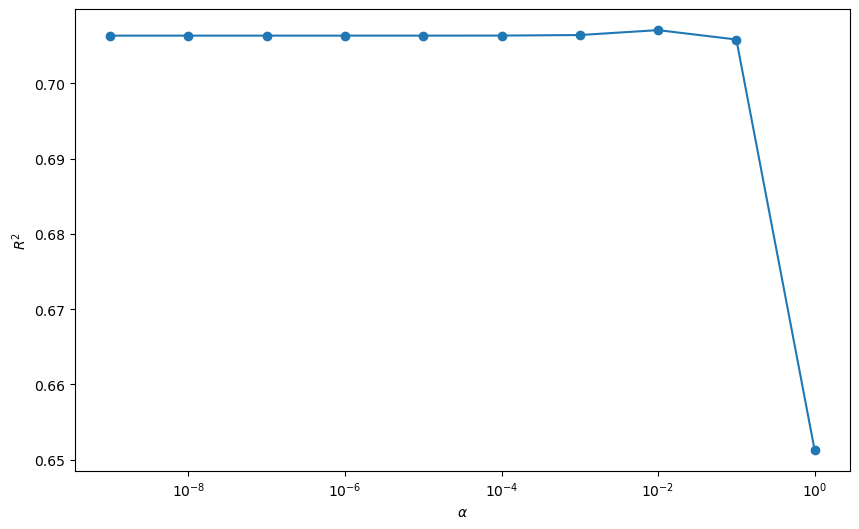

In [55]:
plt.figure(figsize=(10,6))
plt.semilogx(alphas, scores, '-o')
plt.xlabel('$\\alpha$')
plt.ylabel('$R^2$');

**Ejercicio**

Agregue *PolynomialFeatures* a esta *Pipeline* y vuelva a ejecutar la validación cruzada con *PolynomialFeatures* agregada.

**Sugerencia n.° 1:** Las pipelines procesan la entrada de principio a fin. Piense en el orden en que sería lógico agregar las características polinómicas a los datos en secuencia y añádalas en el lugar apropiado de la pipeline.

**Sugerencia n.° 2:** Al hacer esto, debería observar un aumento significativo en la precisión de la validación cruzada.


In [57]:
pf = PolynomialFeatures(degree=2)
scores = []

alphas = np.geomspace(0.001, 10, 5)
for alpha in alphas:
    print(alpha)
    las = Lasso(alpha=alpha, max_iter=100000)
    estimator = Pipeline([
        ("make_higher_degree", pf),
        ("scaler", s),
        ("lasso_regression", las)])
    predictions = cross_val_predict(estimator, X, y, cv = kf)
    score = r2_score(y, predictions)
    
    scores.append(score)
scores

0.001
0.01
0.1
1.0
10.0


[0.8465056899967222,
 0.8552553819994737,
 0.812453647729607,
 0.7090474482089189,
 -0.000616160136140298]

Tenemos una iteración máxima. La idea es que cuando trabajas con regresión de Lasso, en realidad va a funcionar con descenso de gradiente. La idea es que el algoritmo ajuste los coeficientes del modelo iterativamente para llegar al valor óptimo que minimice la función de coste. En este caso, el parámetro <code> max_iter </code> establece el número máximo de iteraciones que el algoritmo realizará durante la optimización. Si el modelo no converge al valor óptimo dentro de esas iteraciones, el proceso se detendrá, lo que podría resultar en un modelo que no ha encontrado la solución óptima.

Si almacenas los resultados en una lista llamada **scores** , funcionará lo siguiente:

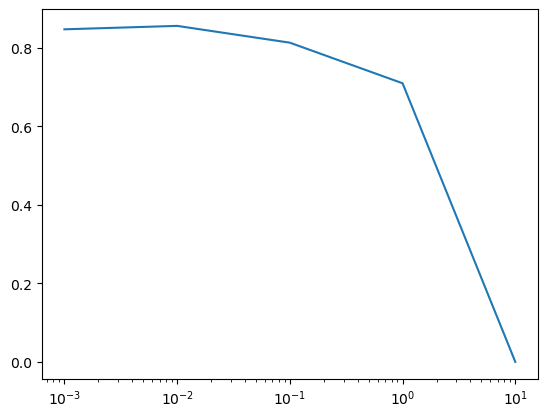

In [59]:
plt.semilogx(alphas, scores);

De lo anterior, observamos que con una $\alpha = 0.01$ tuvimos un $R^2=0.8552$.
Así que vamos a establecer nuestro mejor estiador igual a este valor alfa

In [63]:
# Once we have found the hyperparameter (alpha~1e-2=0.01)
# make the model and train it on ALL the data
# Then release it into the wild .....
best_estimator = Pipeline([
                    ("make_higher_degree", PolynomialFeatures(degree=2)),
                    ("scaler", s),
                    ("lasso_regression", Lasso(alpha=0.01, max_iter=10000))])
best_estimator

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('make_higher_degree', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [65]:
best_estimator.fit(X, y)
best_estimator.score(X, y)

0.9032551408154246

Se eliminan muchas de estas características

In [67]:
best_estimator.named_steps["lasso_regression"].coef_

array([ 0.00000000e+00, -0.00000000e+00, -0.00000000e+00,  0.00000000e+00,
        4.61127587e+00,  0.00000000e+00,  6.24240557e-01,  0.00000000e+00,
       -7.22878514e+00,  9.74968793e+00,  0.00000000e+00,  0.00000000e+00,
        6.34548325e-01,  0.00000000e+00,  9.95741679e-01, -5.51374291e-03,
       -0.00000000e+00,  2.44370838e+00, -2.40444044e+00, -0.00000000e+00,
       -0.00000000e+00, -2.23044443e-01, -0.00000000e+00, -0.00000000e+00,
       -0.00000000e+00, -2.88128934e-01,  5.17203914e-01,  3.07715719e-01,
       -3.39853933e-01, -9.86590910e-02, -0.00000000e+00,  2.72847487e-01,
       -0.00000000e+00, -6.39829763e-01, -3.16474346e-01,  1.44555554e+00,
        0.00000000e+00, -0.00000000e+00, -8.84630187e-01,  1.32081558e+00,
        0.00000000e+00,  0.00000000e+00, -0.00000000e+00,  2.63148300e+00,
       -2.62941147e-01,  0.00000000e+00,  9.08410143e-01, -8.17144528e-01,
        0.00000000e+00, -4.31628234e+00,  5.53254405e-01, -2.91912598e+00,
       -4.68486241e+00,  

## Ridge

- Nuestro objetivo es encontrar los hiperparámetros óptimos para que se generalice bien a los nuevos datos.


Haz lo mismo, pero con regresión **Ridge**

¿Qué modelo, o , rinde mejor con sus hiperparámetros óptimos en el conjunto de datos de Boston? **Ridge o Lasso**

In [118]:
pf = PolynomialFeatures(degree=2)
scores = []

alphas = np.geomspace(0.1, 2, 20)
alphas

array([0.1       , 0.11707799, 0.13707256, 0.1604818 , 0.18788887,
       0.21997651, 0.25754408, 0.30152744, 0.35302227, 0.41331138,
       0.48389667, 0.5665365 , 0.66328955, 0.77656608, 0.90918797,
       1.06445901, 1.24624723, 1.45908123, 1.70826299, 2.        ])

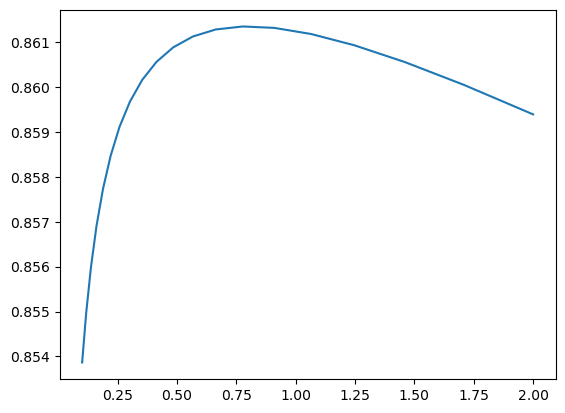

In [120]:
for alpha in alphas:
    ridge = Ridge(alpha=alpha, max_iter=100000)

    estimator = Pipeline([
        ("polynomial_features", pf),
        ("scaler", s),
        ("ridge_regression", ridge)])

    predictions = cross_val_predict(estimator, X, y, cv = kf)
    score = r2_score(y, predictions)
    scores.append(score)
plt.plot(alphas, scores)

In [128]:
resultados = list(zip(alphas, scores))

# Ordenar por el segundo elemento de la tupla (score) de mayor a menor
resultados_ordenados = sorted(resultados, key=lambda x: x[1], reverse=True)

resultados_ordenados


[(0.7765660821766217, 0.8613467465810969),
 (0.909187970690782, 0.8613157070191616),
 (0.6632895500464653, 0.8612804946727317),
 (1.0644590138831427, 0.8611795534634918),
 (0.566536496118536, 0.8611237246559456),
 (1.2462472324355405, 0.8609295140801428),
 (0.48389666535796244, 0.8608819046140794),
 (0.41331138302441095, 0.8605588792363951),
 (1.4590812272681346, 0.8605557549667344),
 (0.35302227018072674, 0.8601566057602424),
 (1.7082629933755134, 0.8600470452272562),
 (0.30152743999357373, 0.8596750594632501),
 (2.0, 0.8593902395694181),
 (0.25754408361413883, 0.859112398556957),
 (0.2199765136004211, 0.8584654302624164),
 (0.1878888687976823, 0.8577303577708344),
 (0.16048180071713392, 0.8569037245063574),
 (0.13707256063767184, 0.8559834219296815),
 (0.11707799137227792, 0.854969602410153),
 (0.1, 0.8538653466411379)]

Recordemos que un:
- $\alpha $ inferior significa más complejidad.
- Observamos que con un $\alpha = 0.1$,no estamos  obteniendo un $R^2$ tan alto (aproximadamente es 0.8539)

A medida que aumentamos el $\alpha $ y reducimos la complejidad, tenemos que el punto óptimo esta alrededor de un $\alpha = 0.77657 $, ya que tiene un $R^2$ alto (0.86134)

**Conclusión**

Tanto la **regresión Lasso** como la **regresión Ridge (Cresta)**, cuando se ajustan adecuadamente los hiperparámetros, dan mejores resultados que la **regresión lineal simple**. Estos modelos regularizados tienen la capacidad de prevenir el sobreajuste (overfitting), lo que les permite generalizar mejor a nuevos datos.

**Ejercicio**

A continuación, sigue los pasos para trabajar con tu mejor modelo y obtener información sobre los coeficientes:

1. **Estandarizar los datos**:
   - Aplica la normalización (escalado) a los datos antes de ajustar el modelo, para asegurarte de que todas las características estén en la misma escala.

2. **Ajustar el modelo y hacer predicciones**:
   - Ajusta tu modelo de regresión Lasso o Ridge con el hiperparámetro seleccionado previamente.
   - Realiza predicciones sobre todo el conjunto de datos, no solo sobre el conjunto de prueba.

3. **Observar los coeficientes más grandes**:
   - Una vez que el modelo esté ajustado, observa cuáles son los coeficientes más grandes para entender qué características están teniendo un mayor impacto en las predicciones.

**Pistas para obtener los coeficientes y sus características correspondientes**

- **Obteniendo los nombres de las características**: 
   - Si has utilizado `PolynomialFeatures` para generar características polinómicas, puedes obtener los nombres de las características generadas utilizando:
     
     ```python
     dict(zip(model.coef_, pf.get_feature_names()))
     ```
     
     
     Esto te dará un diccionario con los coeficientes asociados a cada nombre de característica generada por el transformador `PolynomialFeatures`.

- **Relación de características con el DataFrame original**:
   - Para saber qué características en el DataFrame original corresponden a qué columnas en el conjunto de datos de entrada, puedes utilizar el siguiente código:
     
     ```python
     dict(zip(list(range(len(X.columns.values))), X.columns.values))
     ```
     
     Este código te permite ver la correspondencia entre las columnas del DataFrame original (`X.columns.values`) y las columnas transformadas después de aplicar `PolynomialFeatures`.

**Resumen**

- Establece correctamente los hiperparámetros de tus modelos de **regresión Lasso** o **Ridge** para obtener un mejor rendimiento en comparación con la regresión lineal simple.
- Utiliza el escalado de datos y observa los coeficientes del modelo para interpretar qué características tienen un mayor impacto en las predicciones.
- Usa las funciones de Python indicadas para extraer los nombres de las características generadas por **PolynomialFeatures** y vincúlalas con el conjunto de datos original.



In [131]:
# Once we have found the hyperparameter (alpha~1e-2=0.01)
# make the model and train it on ALL the data
# Then release it into the wild .....
best_estimator = Pipeline([
                    ("make_higher_degree", PolynomialFeatures(degree=2, include_bias=False)),  # Paso 1: Generar características polinómicas de grado 2 sin incluir el sesgo
                    ("scaler", s),  # Paso 2: Aplicar escalado a los datos para normalizarlos
                    ("lasso_regression", Lasso(alpha=0.01, max_iter=10000))  # Paso 3: Aplicar regresión Lasso con el hiperparámetro alpha=0.01
])

best_estimator.fit(X, y)  # Ajusta el modelo completo a TODOS los datos disponibles
best_estimator.score(X, y)  # Evalúa el modelo en los mismos datos, devolviendo el R^2


0.9032551408154246

- Cuanto mayor sea el coeficiente, más impotante se puede ver esa característica en lo que respecta a la predicción del valor medio del hogar.

In [136]:
# Obtener los nombres de las características polinómicas generadas
poly_features = best_estimator.named_steps["make_higher_degree"].get_feature_names_out()
# Obtener los coeficientes del modelo Lasso
lasso_coefs = best_estimator.named_steps["lasso_regression"].coef_
# Crear un DataFrame con las características y sus coeficientes
df_importances = pd.DataFrame(zip(poly_features, lasso_coefs), columns=["Feature", "Coefficient"])
# Ordenar el DataFrame por los coeficientes en valor absoluto de mayor a menor
df_importances["abs_coefficient"] = df_importances["Coefficient"].abs()
df_importances = df_importances.sort_values(by="abs_coefficient", ascending=False).drop(columns="abs_coefficient")

# Mostrar el DataFrame ordenado
df_importances

,Feature,Coefficient
8,RAD,9.749688
68,RM^2,8.594069
7,DIS,-7.228785
72,RM TAX,-6.677045
103,LSTAT^2,5.635229
...,...,...
22,CRIM TAX,-0.000000
40,INDUS NOX,0.000000
19,CRIM AGE,-0.000000
76,AGE^2,-0.000000


In [138]:
col_names_dict = dict(zip(list(range(len(X.columns.values))), X.columns.values))

In [140]:
col_names_dict

{0: 'CRIM',
 1: 'ZN',
 2: 'INDUS',
 3: 'CHAS',
 4: 'NOX',
 5: 'RM',
 6: 'AGE',
 7: 'DIS',
 8: 'RAD',
 9: 'TAX',
 10: 'PTRATIO',
 11: 'B',
 12: 'LSTAT'}

# GridSearchCV

## Para realizar la validación cruzada, utilizamos dos técnicas:
- Usar `KFolds` y crear manualmente un bucle para realizar la validación cruzada.
- Usar `cross_val_predict` y `score` para obtener una puntuación de la validación cruzada en un par de líneas.

Para ajustar los hiperparámetros, observamos un patrón general:
- Usar `cross_val_predict` y `score` en un bucle escrito manualmente sobre los hiperparámetros y luego seleccionar el mejor.

Como era de esperar, existe una función que realiza esto automáticamente: `GridSearchCV`


In [146]:
from sklearn.model_selection import GridSearchCV

# Same estimator as before
estimator = Pipeline([  # Definimos un pipeline que incluye tres pasos
    ("polynomial_features", PolynomialFeatures()),  # Paso 1: Generar características polinómicas
    ("scaler", StandardScaler()),  # Paso 2: Normalizar las características
    ("ridge_regression", Ridge())  # Paso 3: Aplicar regresión Ridge
])

estimator

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('polynomial_features', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [148]:

# Definición de los parámetros a buscar en el grid
params = {
    'polynomial_features__degree': [1, 2, 3],  # Probar diferentes grados de las características polinómicas
    'ridge_regression__alpha': np.geomspace(4, 20, 20)  # Probar valores de alpha en una escala exponencial entre 4 y 20
}

# Crear el objeto GridSearchCV para realizar la búsqueda de hiperparámetros
grid = GridSearchCV(estimator, params, cv=kf)  # cv=kf indica que se usará validación cruzada con KFold (kf)
grid

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...n', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'polynomial_features__degree': [1, 2, ...], 'ridge_regression__alpha': array([ 4. ... 20. ])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and param

In [150]:
grid.fit(X, y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...n', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'polynomial_features__degree': [1, 2, ...], 'ridge_regression__alpha': array([ 4. ... 20. ])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and param

Averiguando cual fue la mejor puntuación y los mejores parámetros.
- La mejor puntuación fue $0.85463$
- El mejor grado del polinomio fue $2$.
- Con el mejor $\alpha =4$ en Ridge

In [152]:
grid.best_score_, grid.best_params_

(0.8546333782070413,
 {'polynomial_features__degree': 2, 'ridge_regression__alpha': 4.0})

In [155]:
y_predict = grid.predict(X)

In [157]:
# This includes both in-sample and out-of-sample
r2_score(y, y_predict)

0.8964707714558113

In [159]:
# Notice that "grid" is a fit object!
# We can use grid.predict(X_test) to get brand new predictions!
grid.best_estimator_.named_steps['ridge_regression'].coef_

array([ 0.00000000e+00,  2.47147038e-01, -1.18377806e+00,  1.11700133e+00,
        1.02268931e+00,  1.11573592e+00,  2.63515343e+00,  1.60400844e+00,
       -2.44378403e+00,  2.67549673e+00,  1.18120641e+00,  3.00931414e-01,
        7.17164316e-01,  5.46697603e-01,  1.16368605e+00,  2.78583120e-01,
        4.15770986e-01,  2.45396270e+00, -1.07012228e+00, -8.15812777e-01,
       -2.95036466e-01, -8.26480829e-01, -4.23552596e-01, -4.33022591e-02,
        8.34930099e-02, -4.92838202e-01,  5.12447325e-01,  5.88355149e-01,
       -3.50662224e-01, -1.39184102e-01, -2.99737738e-01,  1.02696466e+00,
        1.47705864e-02, -6.87593891e-01, -3.12176710e-01,  1.26476807e+00,
        1.01258007e+00, -5.51925730e-01, -8.62269698e-01,  8.78832853e-01,
        6.75975245e-02,  5.91362874e-01, -1.45086000e+00,  1.09286634e+00,
       -7.69112663e-01,  1.16978387e+00,  1.29460196e+00, -7.36888615e-01,
        7.29205860e-01, -2.44086792e+00,  1.02268931e+00, -2.26162754e+00,
       -2.56091292e+00,  

Detalles de todos los valores que saco **GridSearchCV**

In [163]:
pd.DataFrame(grid.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_polynomial_features__degree,param_ridge_regression__alpha,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,0.003802,0.001123,0.000724,5.166645e-04,1,4.000000,"{'polynomial_features__degree': 1, 'ridge_regr...",0.672111,0.748235,0.701801,0.707382,0.031327,60
1,0.003026,0.000192,0.001053,4.826993e-05,1,4.353594,"{'polynomial_features__degree': 1, 'ridge_regr...",0.672098,0.748191,0.702086,0.707458,0.031296,59
2,0.003160,0.000557,0.000910,2.061644e-04,1,4.738444,"{'polynomial_features__degree': 1, 'ridge_regr...",0.672080,0.748139,0.702386,0.707535,0.031264,58
3,0.002564,0.000430,0.000680,4.846626e-04,1,5.157315,"{'polynomial_features__degree': 1, 'ridge_regr...",0.672057,0.748081,0.702699,0.707612,0.031230,57
4,0.002340,0.000449,0.000687,4.859671e-04,1,5.613214,"{'polynomial_features__degree': 1, 'ridge_regr...",0.672027,0.748013,0.703025,0.707689,0.031196,56
5,0.002015,0.000022,0.000982,2.784319e-05,1,6.109413,"{'polynomial_features__degree': 1, 'ridge_regr...",0.671990,0.747935,0.703365,0.707763,0.031160,55
6,0.002542,0.000255,0.000707,5.015224e-04,1,6.649475,"{'polynomial_features__degree': 1, 'ridge_regr...",0.671945,0.747846,0.703716,0.707836,0.031123,53
7,0.002199,0.000335,0.001343,4.591523e-04,1,7.237278,"{'polynomial_features__degree': 1, 'ridge_regr...",0.671889,0.747744,0.704079,0.707904,0.031085,52
8,0.002999,0.000782,0.001571,4.444233e-04,1,7.877042,"{'polynomial_features__degree': 1, 'ridge_regr...",0.671824,0.747628,0.704452,0.707968,0.031047,50
9,0.002571,0.000501,0.000637,4.520460e-04,1,8.573360,"{'polynomial_features__degree': 1, 'ridge_regr...",0.671746,0.747495,0.704834,0.708025,0.031007,48


In [166]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (StandardScaler, 
                                   PolynomialFeatures)
from scipy.stats.mstats import normaltest
from scipy.stats import boxcox
from scipy.special import inv_boxcox

file_name='https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ST0151EN-SkillsNetwork/labs/boston_housing.csv'
boston_data = pd.read_csv(file_name)

lr = LinearRegression()
y_col = "MEDV"
X = boston_data.drop(y_col, axis=1)
y = boston_data[y_col]

pf = PolynomialFeatures(degree=2, include_bias=False)
X_pf = pf.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_pf, y, test_size=0.3, 
                                                    random_state=72018)

s = StandardScaler()
X_train_s = s.fit_transform(X_train)

bc_result = boxcox(y_train)
y_train_bc = bc_result[0]
lam = bc_result[1]

lr.fit(X_train_s, y_train_bc)
X_test_s = s.transform(X_test)
y_pred_bc = lr.predict(X_test_s)

y_pred_tran = inv_boxcox(y_pred_bc, lam)
print(r2_score(y_pred_tran,y_test)) #RES 0.848052537981275

lr = LinearRegression()
lr.fit(X_train_s,y_train)
lr_pred = lr.predict(X_test_s)
r2_score(lr_pred,y_test) #RES 0.8667029116056716


0.8480525388350191


0.8667029116056783

## Resumen

1. Podemos generar pliegues manualmente usando `KFolds`.
2. Podemos obtener una puntuación usando `cross_val_predict(X, y, cv=KFoldObject_or_integer)`.
Esto generará la predicción fuera de la muestra para cada fila.
3. Al seleccionar hiperparámetros, debemos optimizar las puntuaciones fuera de la muestra. Esto significa usar `cross_val_predict` en un bucle, o...
4. ...usar `GridSearchCV`. GridSearchCV toma un modelo (o pipeline) y un diccionario de parámetros para escanear. Encuentra el conjunto de hiperparámetros con la mejor puntuación fuera de la muestra en todos los parámetros y lo llama su "mejor estimador". Luego, reentrena con todos los datos con los "mejores" hiperparámetros.

### Extensiones

Aquí hay algunos aspectos adicionales a tener en cuenta:
* Existe un `RandomSearchCV` que prueba combinaciones aleatorias de parámetros del modelo. Esto puede ser útil si se dispone de un número excesivo de combinaciones para probarlas todas exhaustivamente.
* KFolds seleccionará aleatoriamente las filas que se incluirán en los pliegues de entrenamiento y prueba. Existen otros métodos (como `StratifiedKFolds` y `GroupKFold`) que son útiles cuando se necesita mayor control sobre cómo se dividen los datos (por ejemplo, para evitar fugas de datos). Se pueden crear estos objetos especializados y pasarlos al argumento `cv` de `GridSearchCV`.
